In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
#PINECONE_API_KEY = os.environ['PINECONE_API_KEY']

print("API 키 로드 완료")
print(f"OpenAI Key: {OPENAI_API_KEY[:10]}...")

API 키 로드 완료
OpenAI Key: sk-proj-00...


In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt > LLM(ChatOpenAI) > output_parsers

In [18]:
text = "{topic}에 대해 한 문장으로 설명해줘"

llm = ChatOpenAI(model="gpt-4o-mini")
prompt = PromptTemplate.from_template(text)
output_parsers = StrOutputParser()

In [19]:
chain = prompt | llm | output_parsers
chain

PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}에 대해 한 문장으로 설명해줘')
| ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001D5B2936390>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001D5B2936C60>, root_client=<openai.OpenAI object at 0x000001D5B2934FE0>, root_async_clie

In [21]:
result = chain.invoke({"topic": "랭체인"})
print(result)

랭체인(RLangChain)은 언어 모델을 활용하여 다양한 애플리케이션을 구축하고 데이터와 상호작용할 수 있도록 도와주는 프레임워크입니다.


In [28]:
message = [
  ('system','당신은 대중음악 문화 전문가입니다.'),
  ('human','지금 듣기 좋은 노래 5곡 추천해주세요.')
]
response = llm.invoke(message)
print(response.content)

현재 듣기 좋은 노래 5곡을 추천해 드릴게요. 다양한 장르에서 골라봤으니 취향에 맞는 곡을 찾아보세요!

1. **Olivia Rodrigo - "Vampire"**
   - 강렬한 멜로디와 깊은 감정이 담긴 가사가 인상적인 곡입니다.

2. **SZA - "Kill Bill"**
   - R&B와 힙합이 어우러진 곡으로, 감성을 자극하는 가사가 매력적입니다.

3. **Sam Smith - "Unholy" (ft. Kim Petras)**
   - 팝과 댄스 요소가 결합된 곡으로 신나는 비트가 특징입니다.

4. **Lana Del Rey - "A&W"**
   - 독특한 사운드와 매혹적인 보컬로 리스너를 사로잡는 곡입니다.

5. **Taylor Swift - "Cruel Summer"**
   - 경쾌하고 여름 분위기가 물씬 나는 곡으로, 듣기 좋은 멜로디가 매력적입니다.

이 곡들로 좋은 음악 시간을 보내시길 바랍니다!


In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent   # LangChain 1.x
from langgraph.prebuilt import create_react_agent

In [ ]:
@tool
def add(a: float, b: float) -> float:
  '''두 숫자를 더합니다''' # docstring 
  return a+b

In [32]:
@tool
def multiply(a: float, b: float) -> float:
  '''두 숫자를 곱합니다'''
  return a*b

In [33]:
tools = [ add, multiply ]

In [35]:
agent = create_react_agent(
  prompt='당신은 계산을 도와주는 어시스턴트입니다.',
  model = llm,
  tools = tools
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8564\4211466892.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


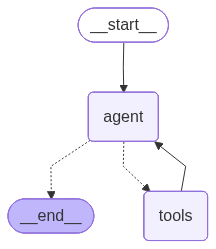

In [ ]:
agent 

점선은 선택, 실선은 필수

In [49]:
result = agent.invoke({
  'messages':[{'role':'user', 
              'content':'3+5를 더한다. 거기에 7을 곱하면?'}]
})
result

{'messages': [HumanMessage(content='3+5를 더한다. 거기에 7을 곱하면?', additional_kwargs={}, response_metadata={}, id='fd19b328-6659-43de-b5f0-8ceb8949b184'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 101, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c6fb6f9a92', 'id': 'chatcmpl-DRuWqI9ZUQWmRctCBSu5h81R8WxCj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d66b3-4eab-7132-9307-be58755f9d4b-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_XMcW2yyBw7Z5edcYI5bteLEO', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 8, 'b': 7}, 'id': 'call_mO9MZvpLt7cIajlkV0NFUNe

In [50]:
for msg in result["messages"]:
    print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 3+5를 더한다. 거기에 7을 곱하면?
[AIMessage] (tool call)
[ToolMessage] 8.0
[ToolMessage] 56.0
[AIMessage] 3 + 5는 8이고, 거기에 7을 곱하면 56입니다.


# 웹검색 에이전트 도구 실습

In [4]:
from langchain_tavily import TavilySearch

In [ ]:
search_tool = TavilySearch(max_results=3) # 도구 정의: 웹 검색

In [5]:
import ast
import operator

In [8]:
SAFE_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
} # 도구 정의: 안전한 계산기

def _safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    elif isinstance(node, ast.BinOp):
        op = SAFE_OPERATORS.get(type(node.op))
        if op is None:
            raise ValueError(f"지원하지 않는 연산자: {node.op}")
        return op(_safe_eval(node.left), _safe_eval(node.right))
    raise ValueError(f"허용되지 않는 표현식: {node}")

In [9]:
@tool
def calculate(expression: str) -> str:
    """사칙연산과 거듭제곱만 허용하는 안전한 계산기입니다. 예: '1234 * 5678'"""
    try:
        tree = ast.parse(expression, mode="eval")
        result = _safe_eval(tree.body)
        return str(result)
    except Exception as e:
        return f"계산 오류: {e}"

In [11]:
# 3. 에이전트 생성
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

agent = create_react_agent(
    model=llm,
    tools=[search_tool, calculate],
    prompt="""당신은 웹 검색과 계산을 도와주는 AI 어시스턴트입니다.

규칙:
- 동일하거나 유사한 검색 쿼리를 반복하지 마세요.
- 검색 결과가 없으면 즉시 그 사실을 사용자에게 알리세요.
- 최대 3번 검색 후 반드시 최종 답변을 제공하세요.""",
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5092\1106597909.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [15]:
# 4. 테스트 실행
result1 = agent.invoke({
    "messages": [{"role": "user", "content": "할인율을 10%라고 가정했을 때, 5년 뒤 1원의 현재가치를 계산하는 법과 그 값을 알려줘."}]
})
print(result1["messages"][-1].content)

계산에 오류가 발생했습니다. 현재가치를 수동으로 계산해보겠습니다.

1. 할인율 \( r = 0.10 \)
2. 기간 \( n = 5 \)
3. 미래가치 \( FV = 1 \)

공식에 따라 계산하면:

\[ PV = \frac{1}{(1 + 0.10)^5} \]

\[ PV = \frac{1}{(1.10)^5} \]

\[ PV = \frac{1}{1.61051} \approx 0.62092 \]

따라서, 5년 뒤 1원의 현재가치는 약 0.62092원입니다.


In [17]:
for msg in result1["messages"]:
    print(f"[{msg.__class__.__name__}] {msg.content[:80] if msg.content else '(tool call)'}")

[HumanMessage] 할인율을 10%라고 가정했을 때, 5년 뒤 1원의 현재가치를 계산하는 법과 그 값을 알려줘.
[AIMessage] (tool call)
[ToolMessage] 계산 오류: 지원하지 않는 연산자: <ast.BitXor object at 0x000002A62A923BD0>
[ToolMessage] 0.1
[AIMessage] 현재가치를 계산하는 방법은 다음과 같습니다:

현재가치(PV)는 미래가치(FV)를 할인율을 사용하여 현재의 가치로 환산하는 것입니다. 공식은 다
[ToolMessage] 계산 오류: 지원하지 않는 연산자: <ast.BitXor object at 0x000002A62A923BD0>
[AIMessage] 계산에 오류가 발생했습니다. 현재가치를 수동으로 계산해보겠습니다.

1. 할인율 \( r = 0.10 \)
2. 기간 \( n = 5 \)
3.
